# EDA de Nueva York: análisis global y partición train/test

La idea es hacer una pequeña exploracion sobre todos los datos sin fijarnos en el precio, eso ya lo haremos en otro notebook solo sobre los datos de entrenamiento. Aquí el precio solo lo miramos para saber si un valor es válido o no (nulo o 0). 

**¿Por qué solo Nueva York?** Comence un estudio con las 10 ciudades vi que muchas relaciones cambiaban bastante de una ciudad a otra y además el precio venía en diez monedas distintas. Nueva York tiene el precio en una unica divisa (USD), la ubicación se puede modelar bien, es la única ciudad que trae `district` completo y es la segunda ciudad con más anuncios, detras de Paris. A partir de ahora los resultados son sobre los anuncios exclusivamente de Nueva York.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import scipy.stats as stats
from scipy.stats import kruskal, mannwhitneyu, spearmanr, chi2_contingency
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))

from func_aux import *
from preparacion_datos import NOMBRES_NY, PAISES_ISO, ambito_host, cargar_listings_ny, limpiar_registros
from particion_datos import (COL_GRUPO, RUTAS, estrato)
from estudio_estratificacion import RUTA_SIMULACION

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
DOCS_DIR = PROJECT_ROOT / "docs"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

RUTA_MANIFIESTO = RUTAS['manifiesto']
LISTING_PATH = DATA_DIR / "listings.csv"
REVIEWS_PATH = DATA_DIR / "reviews.csv"

CIUDAD = 'New York'
pd.set_option('display.max_columns', 40)

## 1. EXTRACCIÓN E INSPECCIÓN DEL DATASET

Cargamos `listings.csv` y `reviews.csv` y nos quedamos con Nueva York. Como `reviews.csv` no tiene columna de
ciudad, las reseñas las filtramos por `listing_id`.

In [3]:
df_all = pd.read_csv(LISTING_PATH, low_memory=False)
rws_all = pd.read_csv(REVIEWS_PATH)

display(df_all["city"].value_counts())

df = df_all[df_all['city'] == CIUDAD].copy().reset_index(drop=True)
df_rws = rws_all[rws_all['listing_id'].isin(df['listing_id'])].copy().reset_index(drop=True)

print(f"Listings {CIUDAD}: {df.shape[0]:,} filas ({df.shape[0]/len(df_all)*100:.1f}% del dataset), {df.shape[1]} columnas")
print(f"Reviews {CIUDAD}:  {df_rws.shape[0]:,} filas ({df_rws.shape[0]/len(rws_all)*100:.1f}% del dataset), {df_rws.shape[1]} columnas")

del df_all, rws_all

city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087
Name: count, dtype: int64

Listings New York: 37,012 filas (13.2% del dataset), 33 columnas
Reviews New York:  847,727 filas (15.8% del dataset), 4 columnas


In [4]:
print("5 ejemplos de listings.csv:")
display(df.sample(5, random_state=42))
print('=' * 60)
print("5 ejemplos de reviews.csv:")
display(df_rws.sample(5, random_state=42))

5 ejemplos de listings.csv:


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
15981,31898478,Skylit Bedroom In Brooklyn,3734323,2012-10-02,"New York, New York, United States",NaN,NaN,NaN,f,0.0,t,t,Bushwick,Brooklyn,New York,40.68800,-73.91409,Private room in apartment,Private room,2,1.0,"[""Refrigerator"", ""Microwave"", ""Kitchen"", ""Coff...",50,30,1125,93.0,10.0,9.0,10.0,10.0,9.0,10.0,t
18080,9473492,1 Bedroom in 2 bdr Bushwick apt,49099055,2015-11-15,"New York, New York, United States",NaN,NaN,NaN,f,1.0,t,t,Bushwick,Brooklyn,New York,40.68983,-73.90512,Private room in apartment,Private room,2,1.0,"[""First aid kit"", ""Hair dryer"", ""Hot tub"", ""Ir...",55,30,1125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f
17909,5757509,Luxury/Midtown East,29867161,2015-03-23,"New York, New York, United States",NaN,NaN,NaN,f,1.0,t,t,Murray Hill,Manhattan,New York,40.74415,-73.97322,Private room in apartment,Private room,2,1.0,"[""First aid kit"", ""Smoke alarm"", ""Essentials"",...",165,30,1125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f
18435,25939748,Modern Apt with private bedroom & bathroom,25210511,2014-12-26,"New York, New York, United States",NaN,NaN,NaN,f,1.0,t,t,Clinton Hill,Brooklyn,New York,40.69468,-73.96587,Private room in apartment,Private room,2,1.0,"[""Shampoo"", ""Air conditioning"", ""Kitchen"", ""Ir...",106,30,1125,99.0,10.0,10.0,10.0,10.0,10.0,10.0,t
18997,15396328,Private Room in Heart of East Village!,14295824,2014-04-14,"New York, New York, United States",NaN,NaN,NaN,f,1.0,t,t,East Village,Manhattan,New York,40.72654,-73.98231,Private room in apartment,Private room,1,1.0,"[""Oven"", ""Hair dryer"", ""Stove"", ""Essentials"", ...",70,30,1125,91.0,10.0,8.0,10.0,10.0,10.0,9.0,f


5 ejemplos de reviews.csv:


,listing_id,review_id,date,reviewer_id
28121,40511239,613270820,2020-03-01,37782837
780588,27540102,346206077,2018-11-07,108378682
331805,470498,33175838,2015-05-25,30414562
831461,41175544,626665881,2020-05-29,267820775
484450,5636395,309687784,2018-08-18,42702619


In [5]:
print('Tipo de dato de las columnas de listings.csv')
df.info()

Tipo de dato de las columnas de listings.csv
<class 'pandas.DataFrame'>
RangeIndex: 37012 entries, 0 to 37011
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   37012 non-null  int64  
 1   name                         36999 non-null  str    
 2   host_id                      37012 non-null  int64  
 3   host_since                   36994 non-null  str    
 4   host_location                36896 non-null  str    
 5   host_response_time           18505 non-null  str    
 6   host_response_rate           18505 non-null  float64
 7   host_acceptance_rate         22379 non-null  float64
 8   host_is_superhost            36994 non-null  str    
 9   host_total_listings_count    36994 non-null  float64
 10  host_has_profile_pic         36994 non-null  str    
 11  host_identity_verified       36994 non-null  str    
 12  neighbourhood                37012 non-n

Hay unas cuantas columnas con el tipo mal, que arreglaremos en el tratamiento de datos:
- `host_since` viene como texto, pero es una fecha.
- `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified` e `instant_bookable` vienen como
  `'t'`/`'f'` y en realidad son booleanos.

Algo que cambia respecto al dataset completo: aquí `district` está relleno en todas las filas. En el global era una columna casi vacía, pero en Nueva York es el distrito del anuncio.

In [6]:
display(df.describe())
print(f"price nulo: {df['price'].isna().sum()} \nprice == 0: {(df['price'] == 0).sum()}")

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,3.701200e+04,3.701200e+04,18505.000000,22379.000000,36994.000000,37012.000000,37012.000000,37012.000000,33404.000000,37012.000000,37012.000000,3.701200e+04,26777.000000,26753.000000,26764.000000,26741.000000,26755.000000,26740.000000,26740.000000
mean,2.510589e+07,9.370949e+07,0.885256,0.804712,23.974158,40.729653,-73.950989,2.797633,1.316399,142.842240,23.323679,5.979924e+04,93.767188,9.586551,9.268009,9.721140,9.712801,9.599589,9.367539
std,1.517880e+07,1.101374e+08,0.250235,0.280852,158.224860,0.054710,0.048291,1.845570,0.722094,275.740987,26.441255,1.116338e+07,9.594491,0.938881,1.146266,0.823948,0.859563,0.794767,1.014201
min,2.595000e+03,2.438000e+03,0.000000,0.000000,0.000000,40.508680,-74.239860,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.103335e+07,9.643914e+06,0.900000,0.730000,1.000000,40.690320,-73.983812,2.000000,1.000000,60.000000,4.000000,9.000000e+01,92.000000,9.000000,9.000000,10.000000,10.000000,9.000000,9.000000
50%,2.485448e+07,4.023649e+07,1.000000,0.940000,1.000000,40.725465,-73.955790,2.000000,1.000000,99.000000,30.000000,1.125000e+03,97.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,3.982193e+07,1.529683e+08,1.000000,1.000000,2.000000,40.762480,-73.933720,4.000000,1.000000,151.000000,30.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.803978e+07,3.870718e+08,1.000000,1.000000,2739.000000,40.912140,-73.710870,16.000000,21.000000,10000.000000,1250.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


price nulo: 0 
price == 0: 28


Cosas raras que salen en el `describe` y que estudiaremos más adelante:
- Hay precios de 0$. Eso no nos sirve como target, así que se quitaran.
- La mediana de `minimum_nights` es 30, o sea, más de la mitad de los anuncios piden
  mínimo un mes.
- `maximum_nights` llega a 2.147.483.647, puede ser un placeholder.
- Hay anuncios con `accommodates == 0` y anfitriones con `host_total_listings_count == 0`.
- Las puntuaciones están muy apretadas arriba: la mediana de `review_scores_rating` es 97 y el percentil 25 ya es 92.

In [7]:
df.nunique().sort_values(ascending=False)

listing_id                     37012
name                           35623
amenities                      31671
host_id                        26765
latitude                       17044
longitude                      13557
host_since                      4000
host_location                   1316
price                            733
maximum_nights                   278
neighbourhood                    220
minimum_nights                   125
host_acceptance_rate              98
host_total_listings_count         79
host_response_rate                77
property_type                     75
review_scores_rating              53
accommodates                      17
bedrooms                          14
review_scores_communication        9
review_scores_accuracy             9
review_scores_value                9
review_scores_checkin              9
review_scores_cleanliness          9
review_scores_location             8
district                           5
host_response_time                 4
r

### 1.1 DUPLICADOS

Queremos saber si hay anuncios repetidos. Miramos tres cosas:
- duplicados exactos o `listing_id` repetidos (esto serían errores al extraer los datos);
- filas iguales en todo menos en el `listing_id`, que podría ser el mismo anuncio publicado dos veces o pisos
  iguales dentro del mismo edificio;
- "gemelos" dentro del mismo anfitrión: mismo tipo, capacidad, dormitorios y barrio. Esto no es un error, pero son prácticamente el mismo producto y nos importa para la partición.

In [8]:
print(f"Duplicados exactos: {df.duplicated().sum()} \nlisting_id repetidos: {df['listing_id'].duplicated().sum()}")

cols_sin_id = [c for c in df.columns if c != 'listing_id']
repetidos = df[df.duplicated(cols_sin_id, keep=False)].sort_values(cols_sin_id)
print(f"Filas identicas salvo el listing_id: {len(repetidos)}")
display(repetidos[['listing_id', 'host_id', 'name', 'room_type', 'neighbourhood', 'accommodates',
                   'latitude', 'longitude','price']])

Duplicados exactos: 0 
listing_id repetidos: 0
Filas identicas salvo el listing_id: 11


,listing_id,host_id,name,room_type,neighbourhood,accommodates,latitude,longitude,price
28814,46753445,359229620,Spectacular Apt | Studio in Brooklyn,Entire place,Fort Greene,1,40.68836,-73.98028,166
28815,46753453,359229620,Spectacular Apt | Studio in Brooklyn,Entire place,Fort Greene,1,40.68836,-73.98028,166
22509,47133162,368944610,Well-kept apartment home | 1BR in New York,Entire place,Murray Hill,3,40.74361,-73.97249,195
22529,47900452,368944610,Well-kept apartment home | 1BR in New York,Entire place,Murray Hill,3,40.74361,-73.97249,195
22508,47130285,368944610,Well-kept apartment home | 1BR in New York,Entire place,Murray Hill,3,40.74361,-73.97249,202
22510,47242698,368944610,Well-kept apartment home | 1BR in New York,Entire place,Murray Hill,3,40.74361,-73.97249,202
22534,48005930,368944610,Well-kept apartment home | 1BR in New York,Entire place,Murray Hill,3,40.74361,-73.97249,202
22519,47530617,368944610,Well-kept apartment home | 1BR in New York,Entire place,Murray Hill,3,40.74361,-73.97249,203
22524,47713309,368944610,Well-kept apartment home | 1BR in New York,Entire place,Murray Hill,3,40.74361,-73.97249,203
28634,45783506,368944610,Well-kept apartment home | 2BR in New York,Entire place,Murray Hill,5,40.74361,-73.97249,338


#### Conclusiones
- No hay duplicados de extracción: ni filas exactas repetidas ni `listing_id` repetidos.
- Hay 11 anuncios que son iguales a otro salvo por el `listing_id`: *"Spectacular Apt | Studio in Brooklyn"*, *"Well-kept apartment home | 1BR/2BR in New York"*, y las coordenadas seran las del edificio.
- Los dejamos. Parecen pisos distintos del mismo edificio que se alquilan por separado, no el mismo anuncio
  duplicado. Y como la partición agrupa por anfitrión, van a caer siempre en el mismo lado, así que no hay
  riesgo de que se cuele información entre train y test.

### 1.2 VALORES NULOS

Valores faltantes por variable en listings (Nueva York):
                             Nulos  Porcentaje
host_response_rate           18507      50.003
host_response_time           18507      50.003
host_acceptance_rate         14633      39.536
review_scores_value          10272      27.753
review_scores_location       10272      27.753
review_scores_checkin        10271      27.750
review_scores_accuracy       10259      27.718
review_scores_communication  10257      27.713
review_scores_cleanliness    10248      27.688
review_scores_rating         10235      27.653
bedrooms                      3608       9.748
host_location                  116       0.313
host_identity_verified          18       0.049
host_since                      18       0.049
host_is_superhost               18       0.049
host_has_profile_pic            18       0.049
host_total_listings_count       18       0.049
name                            13       0.035


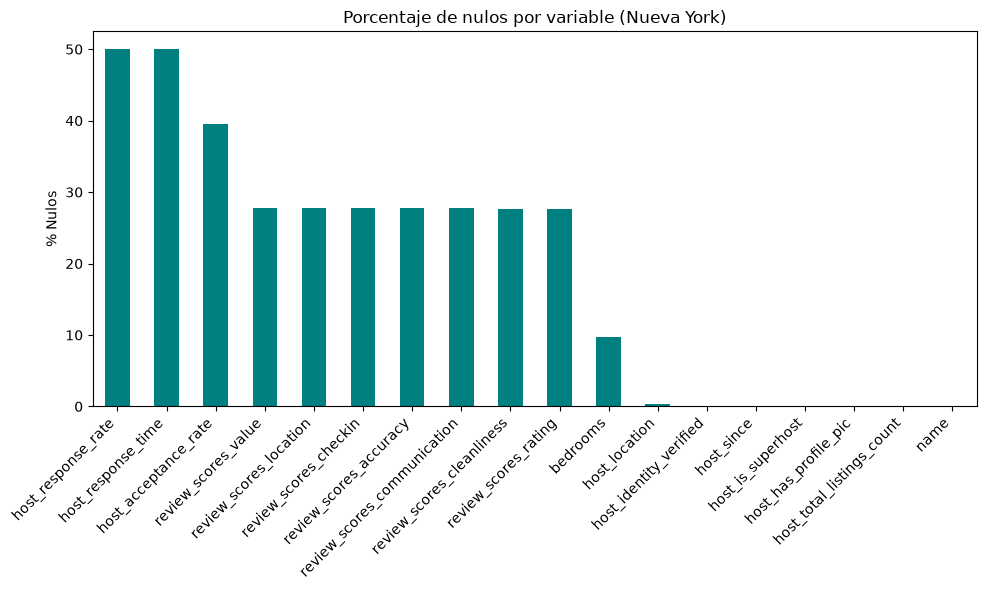

Valores faltantes por variable en reviews:
listing_id     0
review_id      0
date           0
reviewer_id    0
dtype: int64


In [9]:
nulls_df = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje': round(df.isnull().mean() * 100, 3)
}).sort_values(by='Porcentaje', ascending=False)

print("Valores faltantes por variable en listings (Nueva York):")
print(nulls_df[nulls_df['Nulos'] > 0])

fig, ax = plt.subplots(figsize=(10, 6))
nulls_df.loc[nulls_df['Nulos'] > 0, 'Porcentaje'].plot(kind='bar', color='teal', ax=ax)
ax.set_ylabel('% Nulos')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Porcentaje de nulos por variable (Nueva York)')
plt.tight_layout()
plt.show()

print('=' * 60)
print(f"Valores faltantes por variable en reviews:\n{df_rws.isnull().sum()}")

- `host_response_rate` y `host_response_time` faltan en el 50,0% de los anuncios, y `host_acceptance_rate` en
  el 39,5%. Suena al anfitrión que acepta o rechaza sin llegar a escribir mensajes.
- Las `review_scores_*` faltan en un ~27,7%: son los anuncios que no tienen reseñas.
- `bedrooms` falta en un 9,7%, un poco menos que en el global (10,5%).
- Las columnas del anfitrión (`host_since`, `host_is_superhost`...) faltan en las mismas 18 filas (0,05%).
  `district` no tiene ningún nulo.

### ¿Los nulos coinciden entre columnas?

Quiero ver si faltan las mismas filas en varias columnas a la vez o si cada hueco va por su lado. Para eso
calculo la correlación entre los indicadores de nulo (1 si falta, 0 si no): si sale cerca de +1 es que faltan
casi siempre juntas, y cerca de 0 que no tienen nada que ver. Quito las columnas con uno o ningún nulo, porque
su indicador es prácticamente constante y la correlación no tiene sentido.

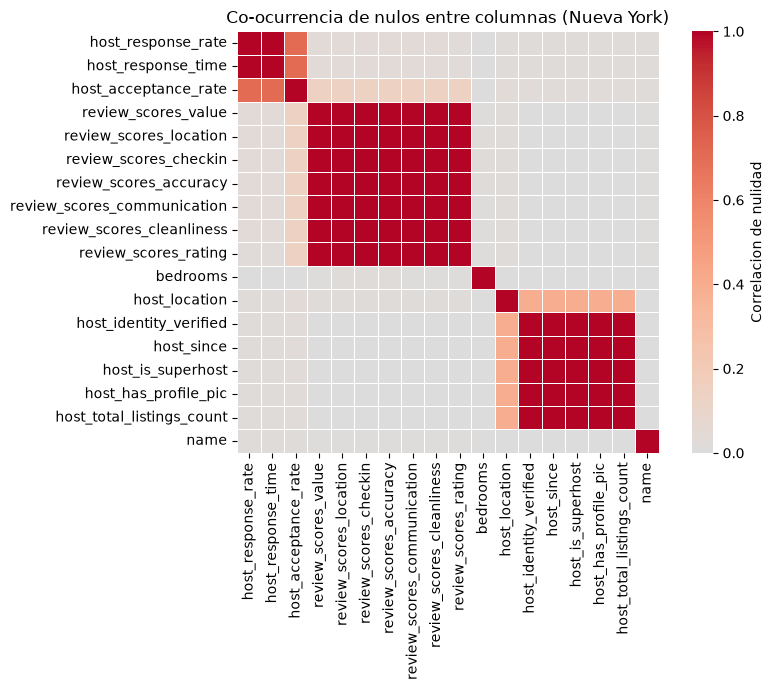

Pares de columnas con mayor co-ocurrencia de nulos:
host_response_rate      host_response_time           1.0
host_is_superhost       host_has_profile_pic         1.0
host_since              host_total_listings_count    1.0
host_identity_verified  host_has_profile_pic         1.0
                        host_total_listings_count    1.0
host_since              host_has_profile_pic         1.0
                        host_is_superhost            1.0
host_identity_verified  host_since                   1.0
                        host_is_superhost            1.0
host_is_superhost       host_total_listings_count    1.0


In [10]:
cols_nulos = nulls_df[nulls_df['Nulos'] > 1].index.tolist()
matriz_nulidad = df[cols_nulos].isnull().astype(int)
corr_nulidad = matriz_nulidad.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_nulidad, cmap='coolwarm', center=0, vmin=0, vmax=1, square=True,
            linewidths=0.4, cbar_kws={'label': 'Correlacion de nulidad'}, ax=ax)
ax.set_title('Co-ocurrencia de nulos entre columnas (Nueva York)')
plt.tight_layout()
plt.show()

pares_coocurrencia = (
    corr_nulidad
    .where(np.triu(np.ones(corr_nulidad.shape, dtype=bool), k=1))
    .stack()
    .dropna()
    .sort_values(ascending=False)
)
print('Pares de columnas con mayor co-ocurrencia de nulos:')
print(pares_coocurrencia.head(10).round(3).to_string())

#### Conclusiones
Los nulos se agrupan en tres bloques que no tienen que ver entre sí (respuesta del anfitrión, perfil del
anfitrión y reseñas), así que cada uno se puede tratar por separado.

- Dentro de cada bloque, en el fondo es un único hueco repartido en varias columnas: `host_response_rate` y
  `host_response_time` faltan justo en las mismas filas, las columnas del anfitrión faltan juntas y las siete
  `review_scores_*` también.
- `host_response_rate` y `host_acceptance_rate` están bastante relacionadas (+0,705), pero no faltan
  exactamente en las mismas filas.
- Un bloque no arrastra a los otros.

In [11]:
brooms = df[df['bedrooms'].isnull()]['room_type'].value_counts()
brooms_pct = (df[df['bedrooms'].isnull()]['room_type'].value_counts() / df['room_type'].value_counts() * 100).round(1)
print('Nulos de bedrooms por room_type:')
display(pd.DataFrame({'n_nulos': brooms, 'pct_del_room_type': brooms_pct}).dropna())

print(f"Anuncios con accommodates == 0: {(df['accommodates'] == 0).sum()}")
display(df.loc[df['accommodates'] == 0, ['room_type', 'accommodates', 'bedrooms', 'price']].value_counts(dropna=False))

Nulos de bedrooms por room_type:


,n_nulos,pct_del_room_type
room_type,,
Entire place,3103.0,16.0
Hotel room,47.0,15.7
Private room,458.0,2.8


Anuncios con accommodates == 0: 13


room_type   accommodates  bedrooms  price
Hotel room  0             NaN       0        13
Name: count, dtype: int64

### ¿Que tipo de apartamento son los anuncios sin `bedrooms`? ¿Son estudios?

Mi sospecha es que muchos anuncios sin `bedrooms` son estudios (sin dormitorio separado). Si es así, el nulo no es un fallo, sino que nos está diciendo algo. Primero buscamos en `property_type`.

In [12]:
df.loc[(df['bedrooms'].isnull()) & (df['room_type'] == 'Entire place'),'property_type'].value_counts()

property_type
Entire apartment             2646
Entire condominium            119
Entire loft                   110
Entire serviced apartment      68
Entire house                   48
Entire guest suite             41
Entire townhouse               21
Room in aparthotel             15
Entire place                   14
Entire guesthouse               8
Entire bungalow                 3
Tiny house                      2
Camper/RV                       2
Room in boutique hotel          1
Houseboat                       1
Entire home/apt                 1
Boat                            1
Barn                            1
Cave                            1
Name: count, dtype: int64

Con `property_type` no hay manera: ningún valor dice *studio*, así que supongo que los estudios están metidos
dentro de `Entire apartment`. Probamos a buscar *studio* en el título del anuncio (`name`).

In [13]:
entire_all = df[df['room_type'] == 'Entire place']
es_studio = entire_all['name'].fillna('').str.contains(r'\b(?:studio|estudio)s?\b', case=False, regex=True, na=False)
sin_bed = entire_all['bedrooms'].isna()

tabla_studio = pd.DataFrame({
    'n': [sin_bed.sum(), (~sin_bed).sum()],
    'pct_titulo_studio': [es_studio[sin_bed].mean() * 100, es_studio[~sin_bed].mean() * 100],
    'mediana_accommodates': [entire_all.loc[sin_bed, 'accommodates'].median(),
                             entire_all.loc[~sin_bed, 'accommodates'].median()],
}, index=['bedrooms nulo', 'bedrooms informado']).round(1)

print('Presencia de "studio" en el titulo (room_type = Entire place & bedrooms = null)')
display(tabla_studio)

print('Distribucion de accommodates en Entire place con bedrooms nulo:')
print((entire_all.loc[sin_bed, 'accommodates'].value_counts(normalize=True).sort_index()).round(3).to_string())

Presencia de "studio" en el titulo (room_type = Entire place & bedrooms = null)


,n,pct_titulo_studio,mediana_accommodates
bedrooms nulo,3103,69.9,2.0
bedrooms informado,16294,4.2,4.0


Distribucion de accommodates en Entire place con bedrooms nulo:
accommodates
1     0.062
2     0.612
3     0.171
4     0.125
5     0.013
6     0.010
7     0.001
8     0.001
9     0.000
10    0.001
15    0.000
16    0.003


#### Conclusiones
Se confirma nuestra sospecha. En la mayoría de los casos, que falte `bedrooms` significa que no hay dormitorio separado, es decir, que es un estudio.

- El 69,9% de los `Entire place` sin `bedrooms` pone *studio* en el título, frente al 4,1% de los que sí tienen el dato. Además son alojamientos pequeños (el 61,2% son para 2 personas justas).
- Qué vamos a hacer: crear una variable `es_estudio` (nulo en `bedrooms` o *studio* en el título) antes de
  imputar, y luego imputar `bedrooms` con la mediana por `room_type` × `accommodates`, redondeada. Ojo, que las
  medianas se calculan solo con el train, dentro de `PreparadorListings`. Aquí no se imputa nada.

## 2. ANÁLISIS Y TRATAMIENTO DE DATOS

En esta parte pasamos cada variable a su tipo, revisamos que la localización tenga sentido y sacamos las
variables nuevas que vamos a necesitar después.

In [14]:
# Normalizacion de tipos de datos y mapeo de booleanos
df['host_since'] = pd.to_datetime(df['host_since'])
df_rws['date'] = pd.to_datetime(df_rws['date'])

map_bool = {'t': True, 'f': False}
cols_bool = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
for col in cols_bool:
    if not pd.api.types.is_bool_dtype(df[col]):  # idempotente: no re-mapear si ya es booleana
        df[col] = df[col].map(map_bool).astype('boolean')

df['host_is_superhost'] = df['host_is_superhost'].fillna(False)
df['host_identity_verified'] = df['host_identity_verified'].fillna(False)
df['instant_bookable'] = df['instant_bookable'].fillna(False)

print(df[cols_bool + ['host_since']].dtypes.to_string())

host_is_superhost                boolean
host_has_profile_pic             boolean
host_identity_verified           boolean
instant_bookable                 boolean
host_since                datetime64[us]


### 2.1 FILAS NO VÁLIDAS

Como `bedrooms` no lo imputamos aquí, solo quitamos las filas
que directamente no se pueden usar:

- `accommodates == 0` (13 anuncios, todos `Hotel room` y con precio 0). Si no cabe nadie, no hay nada que
  alquilar.
- Precio nulo o 0. Es el target, y si lo imputáramos nos estaríamos inventando observaciones fáciles de
  predecir que harían que la validación saliera mejor de lo que es.

Son reglas de si el dato es válido o no, no dependen de cómo se distribuye el precio.

In [15]:
n_antes = len(df)
df = df[df['accommodates'] > 0].copy()
print(f"Filas eliminadas por accommodates = 0:    {n_antes - len(df)}")

n_antes_2 = len(df)
df = df[df['price'] > 0].dropna(subset=['price']).copy().reset_index(drop=True)
print(f"Filas eliminadas por precio nulo o cero:  {n_antes_2 - len(df)}")

# Las mismas filas que parte la particion: si no coincidieran, este notebook describiria otro dataset
validos = limpiar_registros(cargar_listings_ny(LISTING_PATH))
assert df['listing_id'].tolist() == validos['listing_id'].tolist()
print(f"Anuncios validos: {len(df):,}")

Filas eliminadas por accommodates = 0:    13
Filas eliminadas por precio nulo o cero:  15
Anuncios validos: 36,984


### 2.2 LOCALIZACION: DISTRITO, BARRIO Y UBICACION

En el global `district` era casi completamente nulo, pero aquí esta completa y seguramente sea una
columna geográfica que nos pueda aportar bastante para nuestro analisis. Antes de usarla como nivel intermedio entre ciudad y barrio, compruebo que la jerarquía está bien, es decir, que ningún barrio aparece en dos distritos distintos.

Barrios: 220
Barrios presentes en mas de un district: 0
Barrios con menos de 30 anuncios: 106 (48.2% de los barrios, 2.8% de los anuncios)


,n_anuncios,n_barrios,mediana_anuncios_por_barrio,pct_anuncios
district,,,,
Manhattan,16528,32,270.0,44.7
Brooklyn,14472,48,97.5,39.1
Queens,4704,49,41.0,12.7
Bronx,991,49,16.0,2.7
Staten Island,289,42,3.5,0.8


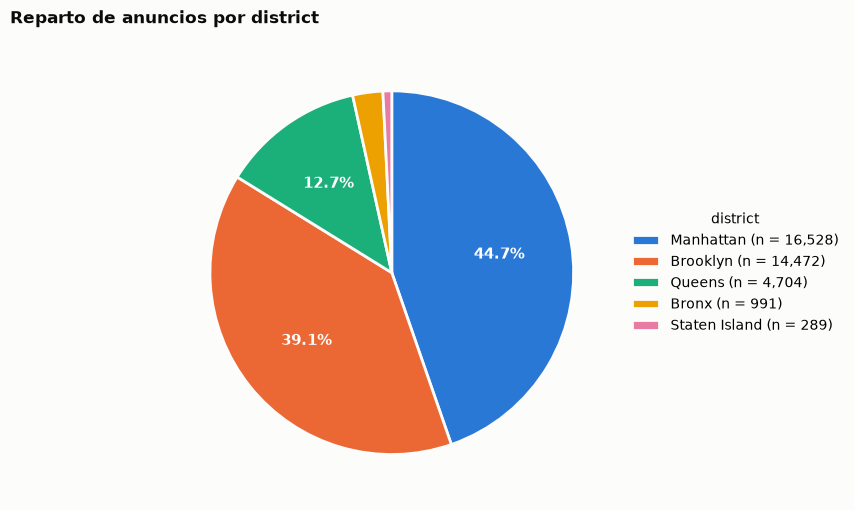

In [16]:
from func_aux import grafico_reparto_pie, grafico_barras_apiladas

tam_barrio = df['neighbourhood'].value_counts()
barrios_multi = (df.groupby('neighbourhood')['district'].nunique() > 1).sum()
print(f"Barrios: {len(tam_barrio)}")
print(f"Barrios presentes en mas de un district: {barrios_multi}")
print(f"Barrios con menos de 30 anuncios: {(tam_barrio < 30).sum()} "
      f"({(tam_barrio < 30).mean()*100:.1f}% de los barrios, "
      f"{tam_barrio[tam_barrio < 30].sum() / len(df) * 100:.1f}% de los anuncios)")

ORDEN_DISTRICT = df['district'].value_counts().index.tolist()
resumen_district = df.groupby('district').agg(
    n_anuncios=('listing_id', 'size'),
    n_barrios=('neighbourhood', 'nunique'),
    mediana_anuncios_por_barrio=('neighbourhood', lambda s: s.value_counts().median()),
).loc[ORDEN_DISTRICT]
resumen_district['pct_anuncios'] = (resumen_district['n_anuncios'] / len(df) * 100).round(1)
display(resumen_district)

COLOR_DISTRICT = {'Manhattan': '#2a78d6', 'Brooklyn': '#eb6834', 'Queens': '#1baf7a',
                  'Bronx': '#eda100', 'Staten Island': '#e87ba4'}
grafico_reparto_pie(df, 'district', {b: COLOR_DISTRICT[b] for b in ORDEN_DISTRICT},
                    titulo='Reparto de anuncios por district')


Una vez visto como se distribuyen los anuncios por distrito, veamos como se distribuyen por distrito y tipo de habitacion.

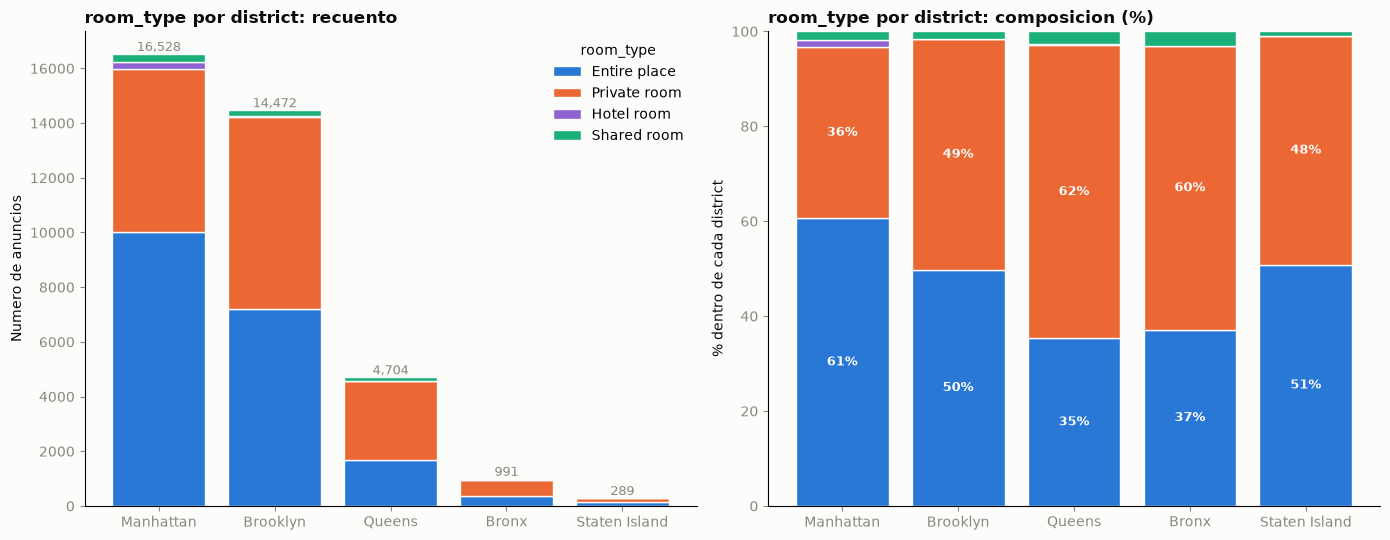

In [17]:
COLOR_ROOM_TYPE = {'Entire place': '#2a78d6', 'Private room': '#eb6834',
                   'Hotel room': '#8f63d2', 'Shared room': '#1baf7a'}
conteo_district_rt = grafico_barras_apiladas(df, 'district', 'room_type', ORDEN_DISTRICT, COLOR_ROOM_TYPE)

#### Conclusiones
`district` está limpio como jerarquía, pero la oferta está muy concentrada: dos distritos tienen el 84% de los
anuncios y la mitad de los barrios tiene menos de 30.

- Manhattan (44,7%) y Brooklyn (39,1%) juntos son el 83,8% de los anuncios. El Bronx (2,7%) y Staten Island
  (0,8%) son muy pequeños, así que cualquier comparación con ellos va a tener pocas observaciones detrás.
- Con los barrios pasa lo contrario: hay 220, y el 48,2% tiene menos de 30 anuncios (aunque entre todos solo suman el 2,8% de la oferta). En Staten Island la mediana es de 3,5 anuncios por barrio.
- El tipo de alojamiento cambia bastante según el distrito. En Manhattan el 60,6% son pisos enteros, mientras que en Queens y el Bronx ganan las habitaciones privadas. Los hoteles están casi todos en Manhattan (247/271). Esto quiere decir que parte de la diferencia de precio entre distritos puede venir de esta mezcla, así que habrá que compararlos también dentro de cada `room_type`.

### 2.3 ¿DONDE VIVEN LOS ANFITRIONES? (`host_ambito`)

Queremos saber si los anfitriones viven en Nueva York, en otra parte de EE. UU. o fuera del país a ver si nos aporta informacion.

El problema es que `host_location` está escrito de cualquier manera (código ISO, ciudad, ciudad y país, solo elpaís...). No la tocamos, sino que creamos una variable nueva con cuatro valores: `misma_ciudad`, `mismo_pais`, `extranjero` y `desconocido`.

- Contamos como misma ciudad tanto *New York* como cualquiera de los cinco distritos, porque mucha gente pone
  cosas como "Brooklyn, NY".
- Para sacar el país uso un diccionario hecho a mano con nombres y códigos, y si no encuentra nada tiro de
  *pycountry* (solo pycountry era muy ineficiente).

In [18]:
# Primero solo con el diccionario de paises de preparacion_datos (el ultimo elemento suele ser el pais)
misma_ciudad = df['host_location'].fillna('').str.lower().str.contains('|'.join(NOMBRES_NY))
host_iso = df['host_location'].str.split(',').str[-1].str.strip().str.lower().map(PAISES_ISO)

df['host_ambito'] = np.select(
    [misma_ciudad, host_iso == 'US', host_iso.notna()],
    ['misma_ciudad', 'mismo_pais', 'extranjero'],
    default='desconocido',
)

print('Distribucion de host_ambito (% del total):')
print(pd.DataFrame({
    'Conteo': df['host_ambito'].value_counts(),
    'Porcentaje (%)': (df['host_ambito'].value_counts(normalize=True) * 100).round(2)
}).to_string())

display(df[df['host_ambito'] == 'desconocido'].sample(5, random_state=42)[['host_location', 'district', 'neighbourhood']])

Distribucion de host_ambito (% del total):
              Conteo  Porcentaje (%)
host_ambito                         
misma_ciudad   28663           77.50
mismo_pais      6512           17.61
extranjero       944            2.55
desconocido      865            2.34


,host_location,district,neighbourhood
7372,PH,Manhattan,Midtown
28039,"Long Island, NY",Manhattan,East Village
21504,CA,Manhattan,Upper West Side
10815,UA,Brooklyn,Bedford-Stuyvesant
1007,IT,Manhattan,Hell's Kitchen


In [19]:
# Version final: diccionario y, si no esta, pycountry como respaldo (la misma que usa el preparador)
df['host_ambito'] = ambito_host(df['host_location'])

print('Distribucion de host_ambito:')
print(pd.DataFrame({
    'Conteo': df['host_ambito'].value_counts(),
    'Porcentaje (%)': (df['host_ambito'].value_counts(normalize=True) * 100).round(2)
}).to_string())

print('Ejemplos de alojamientos con localizacion del host desconocida:')
display(df[df['host_ambito'] == 'desconocido'].sample(5, random_state=42)[['host_location', 'district', 'neighbourhood']])

Distribucion de host_ambito:
              Conteo  Porcentaje (%)
host_ambito                         
misma_ciudad   28663           77.50
mismo_pais      6523           17.64
extranjero      1646            4.45
desconocido      152            0.41
Ejemplos de alojamientos con localizacion del host desconocida:


,host_location,district,neighbourhood
15852,I'm a digital nomad!,Brooklyn,Williamsburg
34583,NaN,Brooklyn,Williamsburg
23351,TEL AVIV,Manhattan,Hell's Kitchen
17366,NaN,Brooklyn,Bushwick
32095,Resplendent Residence in heart of Harlem revival,Manhattan,Harlem


Con *pycountry* de apoyo, los `desconocido` bajan de 865 a 152. Al principio probé a usar solo la librería, pero
iba demasiado lento, por eso la pongo detrás del diccionario. Los 152 que quedan no tienen una localización
aprovechable (son nulos o texto libre), así que lo damos por bueno.

Resultado: Nueva York es un mercado de anfitriones locales. 3 de cada 4 viven en la ciudad, y esto apenas
cambia de un distrito a otro.

### 2.4 NULOS EN REVIEWS

Si un anuncio no tiene ninguna puntuación en `listings.csv`, ¿tampoco tiene reseñas en `reviews.csv`? ¿O los
dos ficheros no cuadran?

In [20]:
cols_reviews = [x for x in df.columns if x.startswith('review_scores')]
lids = df.loc[df[cols_reviews].isnull().all(axis=1), 'listing_id']
print(f"Anuncios sin ninguna puntuacion: {len(lids):,} de {len(df):,} ({len(lids)/len(df)*100:.2f}%)")
has_review = lids[lids.isin(df_rws['listing_id'])]
print(f"Sin puntuacion en listings.csv pero con reseña en reviews.csv: {len(has_review):,}")

Anuncios sin ninguna puntuacion: 10,202 de 36,984 (27.58%)
Sin puntuacion en listings.csv pero con reseña en reviews.csv: 707


Pues no cuadran del todo: 707 de los 10.202 anuncios sin puntuación sí tienen alguna reseña en `reviews.csv`.
Lo más probable es que sean reseñas recientes que todavía no se habían reflejado en la puntuación media. De todas
formas no podemos usarlas para imputar, porque `reviews.csv` solo trae identificadores y fechas, no notas (csv totalmente inutil).

### 2.5 ACTIVIDAD EN RESEÑAS Y ANFITRIONES

Para tener algo de contexto temporal del mercado (sin mirar el precio), vemos cuántas reseñas se escriben cada
mes y cuántos anfitriones se dan de alta. Las reseñas no las vamos a usar como variables, porque son posteriores
a la publicación del anuncio, pero sirven para ver cuánta actividad hay.

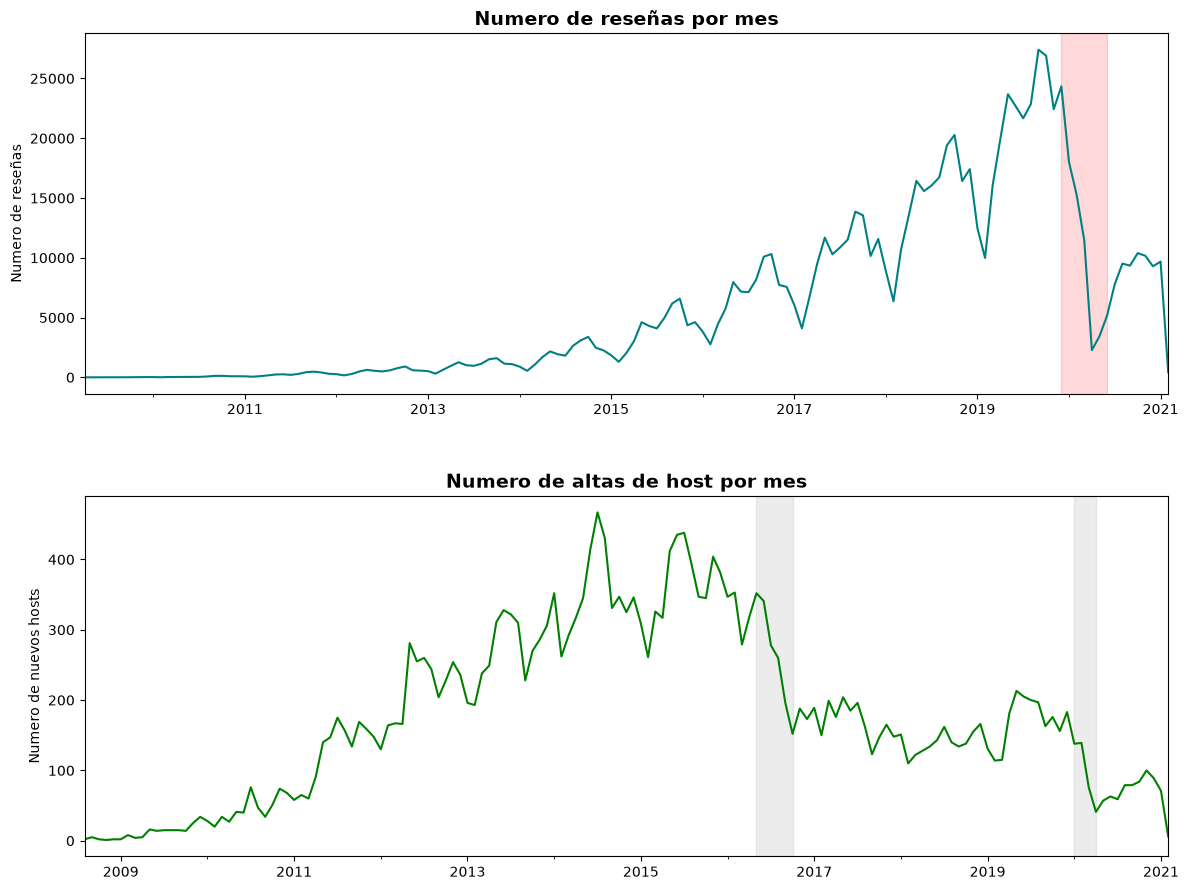

Reseñas por año (2016-2021):
date
2016     82958
2017    119926
2018    177846
2019    250469
2020    112173
2021     10110

Mes con mas reseñas: 2019-09 (27,406)
Año con mas altas de host: 2015.0


In [21]:
df_rws['month'] = df_rws['date'].dt.to_period('M')
anual = df_rws.groupby(df_rws['date'].dt.year).size()

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
serie_rws = df_rws['month'].value_counts().sort_index()
serie_rws.plot(kind='line', ax=axes[0], color='teal')
axes[0].axvspan(pd.Period('2019-12', 'M'), pd.Period('2020-06', 'M'), color='red', alpha=0.15)
axes[0].set_title('Numero de reseñas por mes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Numero de reseñas')

altas = df.groupby('host_id')['host_since'].min().dt.to_period('M').value_counts().sort_index()
altas.plot(kind='line', ax=axes[1], color='green')
axes[1].axvspan(pd.Period('2016-05', 'M'), pd.Period('2016-10', 'M'), color='gray', alpha=0.15)
axes[1].axvspan(pd.Period('2020-01', 'M'), pd.Period('2020-04', 'M'), color='gray', alpha=0.15)
axes[1].set_title('Numero de altas de host por mes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Numero de nuevos hosts')
fig.tight_layout(h_pad=4)
plt.show()

print('Reseñas por año (2016-2021):')
print(anual.loc[2016:].to_string())
print(f"\nMes con mas reseñas: {serie_rws.idxmax()} ({serie_rws.max():,})")
print(f"Año con mas altas de host: {df['host_since'].dt.year.value_counts().idxmax()}")

#### Conclusiones
- El COVID se nota muchísimo: se pasa de 250.469 reseñas en 2019 a 112.173 en 2020 (−55%). El mes con más
  reseñas es septiembre de 2019 (27.406). Las 10.110 reseñas de 2021 son solo hasta febrero, así que no se pueden comparar con años enteros.
- La serie tiene tendencia y estacionalidad, y las subidas y bajadas de cada año son más grandes cuanto más alto está el nivel, lo que apunta a algo multiplicativo.


## 3. PARTICIÓN TRAIN / TEST

A partir de aquí el análisis se separa. La partición se hace una sola vez con `scripts/particion_datos.py` y se guarda en `data/particion/`, y a partir de ahí todo tira de esos ficheros:

| Fichero | Qué tiene |
|---|---|
| `listings_train.csv`, `listings_test.csv` | Las filas tal cual vienen en `listings.csv`, solo los anuncios válidos |
| `particion.csv` | `listing_id`, `host_id`, `conjunto` |

### 3.1 ¿AGRUPAR POR HOST?

In [22]:
tam_cartera = df.groupby(COL_GRUPO)['listing_id'].transform('size')
print(f"Anfitriones con un solo anuncio: "
      f"{(df.groupby(COL_GRUPO).size() == 1).mean():.1%} ({df[COL_GRUPO].nunique():,} total)")
print(f"Anuncios en carteras de mas de 1: {(tam_cartera > 1).mean():.1%} | de 5 o mas: {(tam_cartera >= 5).mean():.1%} "
      f"| de 10 o mas: {(tam_cartera >= 10).mean():.1%}")
print(f"Las 8 carteras de alojamientos mayores: {df.groupby(COL_GRUPO).size().nlargest(8).tolist()}")

clave_gemelo = [COL_GRUPO, 'room_type', 'accommodates', 'bedrooms', 'neighbourhood']
n_gemelos = df.groupby(clave_gemelo, dropna=False)['listing_id'].transform('size')
print(f"Anuncios con un 'gemelo' en su cartera: "
      f"{(n_gemelos > 1).sum():,} ({(n_gemelos > 1).mean():.1%} del total)")

Anfitriones con un solo anuncio: 85.6% (26,742 total)
Anuncios en carteras de mas de 1: 38.1% | de 5 o mas: 16.6% | de 10 o mas: 10.9%
Las 8 carteras de alojamientos mayores: [255, 181, 164, 136, 122, 121, 117, 88]
Anuncios con un 'gemelo' en su cartera: 8,750 (23.7% del total)


#### Conclusiones
Los anuncios de un mismo anfitrión no son independientes entre sí, así que la partición tiene que mantenerlos
juntos.

- El 85,6% de los anfitriones tiene un solo anuncio, pero el 38,1% de los anuncios son de anfitriones con más de uno, y el 10,9% de anfitriones con 10 o más (el más grande tiene 255).
- El 23,7% de los anuncios tiene un "gemelo" (mismo room_type, capacidad, dormitorios y barrio) del mismo anfitrión. Si partimos por filas, uno acaba en train y el otro en test, el modelo lo "reconoce" y el error en test sale mejor de lo que realmente es.
- Esto es lo que se recomienda para datos jerárquicos (Roberts et al., 2017, *Ecography*), y que train y test no sean independientes está recogido como un tipo de fuga de datos (Kapoor y Narayanan, 2023, *Patterns*). 

### 3.2 ¿ESTRATIFICAR LA PARTICION?

Al agrupar movemos bloques enteros de anuncios de golpe, así que por azar el test puede quedar más desequilibrado
que con un split normal. Estratificar no cambia lo que aprende el modelo, pero hace que la composición del test
varíe menos, y eso me interesa porque más adelante quiero ver el error por distrito y por tipo de alojamiento y
necesito tener suficientes anuncios en cada grupo.

Para decidirlo he simulado 50 particiones agrupadas (20% de test) con cada opción (`estudio_estratificacion.py`)
y he medido la mayor diferencia, en puntos porcentuales, entre el peso de cada categoría en train y en test. Solo
uso variables explicativas, el precio no pinta nada en esta decisión.

In [23]:
print('Anuncios por celda room_type x district (el estrato candidato):')
display(pd.crosstab(df['district'], df['room_type'], margins=True))

simulacion = pd.read_csv(RUTA_SIMULACION)
resumen_sim = simulacion.groupby('estrategia', sort=False).agg(
    desv_room_type_media=('desv_room_type', 'mean'), desv_room_type_max=('desv_room_type', 'max'),
    desv_district_media=('desv_district', 'mean'), desv_district_max=('desv_district', 'max'),
    desv_celda_max=('desv_celda', 'max'),
    hotel_test_min=('hotel_en_test', 'min'), hotel_test_max=('hotel_en_test', 'max'),
    shared_test_max=('shared_en_test', 'max'), staten_test_max=('staten_en_test', 'max'),
)
esperado = (df['room_type'].value_counts() * 0.2).round()
print(f"Esperado en un test del 20%: Hotel room {esperado['Hotel room']:.0f} | Shared room {esperado['Shared room']:.0f} | "
      f"Staten Island {(df['district'] == 'Staten Island').sum() * 0.2:.0f}")
display(resumen_sim.round(2))

Anuncios por celda room_type x district (el estrato candidato):


room_type,Entire place,Hotel room,Private room,Shared room,All
district,,,,,
Bronx,368,0,592,31,991
Brooklyn,7206,15,7021,230,14472
Manhattan,10014,247,5975,292,16528
Queens,1662,9,2903,130,4704
Staten Island,147,0,139,3,289
All,19397,271,16630,686,36984


Esperado en un test del 20%: Hotel room 54 | Shared room 137 | Staten Island 58


,desv_room_type_media,desv_room_type_max,desv_district_media,desv_district_max,desv_celda_max,hotel_test_min,hotel_test_max,shared_test_max,staten_test_max
estrategia,,,,,,,,,
sin estratificar,1.59,5.45,1.84,4.45,6.17,19,104,205,83
room_type,0.01,0.02,1.36,3.31,2.59,54,55,138,79
district,1.84,3.54,0.01,0.02,2.35,17,90,199,58
room_type x district,0.07,0.10,0.08,0.10,0.09,57,60,140,58


#### Conclusiones
Me quedo con estratificar por `room_type` × `district`, porque es la única opción que equilibra las dos a la vez.

- No estratificar sale caro: en el peor caso el test tiene casi el doble de habitaciones de hotel de las que
  debería y el reparto por distrito se va más de 4 puntos. Pasa porque las habitaciones de hotel están en muy
  pocos anfitriones.
- Con el estrato combinado todas las diferencias quedan por debajo de 0,1 puntos, también en las 18 celdas.
- Los folds de la validación cruzada usan este mismo estrato (`func_modelado.generar_folds`).